# GACC vs. bit-width — augmented points from a single x₀

All 100 JSON files in `results/volumes_mlp_walk1point/` come from augmented points
generated by the MCMC walk from a **single** original x₀ (MLP, FashionMNIST, seed 42).
Every point x' is inside Polytope #1 of x₀ but (typically) in a different
activation-pattern region of the q-model.

**Generalized accuracy (GACC)**:
$$\mathrm{GACC}(b) = \frac{\sum_{i} W^{\mathrm{both}}_i(b)}{\sum_{i} W^{\mathrm{correct}}_i(b)}$$
where the sums run over the chosen subset of augmented points,
$W^{\mathrm{correct}}_i(b)$ = mean width of P2 (q-model activation region) and
$W^{\mathrm{both}}_i(b)$ = mean width of P3 (P2 ∩ q-model classifies c).

We plot one GACC curve per subset size: **1, 10, 25, 50, 100 points**.

## Setup

In [2]:
%load_ext autoreload
%autoreload 2

import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


## Load results

In [48]:
MODEL = "cnn"  # "mlp" or "cnn"
RESULTS_DIR = ROOT / "results" / f"volumes_{MODEL}_walk1point"

def load_records(results_dir):
    recs = []
    for f in sorted(Path(results_dir).glob("volumes_sample*.json"),
                    key=lambda p: int(p.stem.split("sample")[1])):
        with open(f) as fh:
            recs.append(json.load(fh))
    return recs

records = load_records(RESULTS_DIR)
print(f"Found {len(records)} result files.")

bits_grid = sorted(int(b) for b in records[0]["widths_both"].keys())
print("Bits grid:", bits_grid)

Found 50 result files.
Bits grid: [4, 6, 8, 10, 12, 16]


In [49]:
records[13]

{'model_type': 'cnn',
 'sample_idx': 13,
 'model_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/checkpoints/fashion_cnn_best.pth',
 'data_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/data/fashionMNIST_augmented_cnn_seed42_walk.pt',
 'n_directions': 200,
 'n_directions_used': 200,
 'bits_grid': [4, 6, 8, 10, 12, 16],
 'width_base': 1.5175357966138596,
 'widths_correct': {'4': 0.7478961955189835,
  '6': 1.0934353957807519,
  '8': 1.3115174526208555,
  '10': 1.4090858631691379,
  '12': 1.4395977061792087,
  '16': 1.4874876182454497},
 'widths_both': {'4': 0.7478961955150489,
  '6': 1.093435395751702,
  '8': 1.3115174521439517,
  '10': 1.4090858633870664,
  '12': 1.4395977638308524,
  '16': 1.487487617888213}}

## Compute GACC for each subset size

Subsets are the first N records sorted by `sample_idx` (i.e. indices 0…N-1).
NaN widths (empty polytope = q-model misclassifies) are treated as 0.

In [50]:
records[13]

{'model_type': 'cnn',
 'sample_idx': 13,
 'model_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/checkpoints/fashion_cnn_best.pth',
 'data_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/data/fashionMNIST_augmented_cnn_seed42_walk.pt',
 'n_directions': 200,
 'n_directions_used': 200,
 'bits_grid': [4, 6, 8, 10, 12, 16],
 'width_base': 1.5175357966138596,
 'widths_correct': {'4': 0.7478961955189835,
  '6': 1.0934353957807519,
  '8': 1.3115174526208555,
  '10': 1.4090858631691379,
  '12': 1.4395977061792087,
  '16': 1.4874876182454497},
 'widths_both': {'4': 0.7478961955150489,
  '6': 1.093435395751702,
  '8': 1.3115174521439517,
  '10': 1.4090858633870664,
  '12': 1.4395977638308524,
  '16': 1.487487617888213}}

In [51]:
SUBSET_SIZES = [1, 10, 25, 50]

def safe(v):
    return 0.0 if (v is None or math.isnan(v)) else float(v)
#    return v

def gacc_for_subset(recs, bits_grid):
    """Returns dict {bits: GACC} for the given list of records."""
    sum_correct = {b: sum(safe(r["widths_correct"][str(b)]) for r in recs)
                   for b in bits_grid}
    sum_both    = {b: sum(safe(r["widths_both"][str(b)])    for r in recs)
                   for b in bits_grid}
    return {
        b: (sum_both[b] / sum_correct[b] if sum_correct[b] > 0 else float("nan"))
        for b in bits_grid
        }

gacc_by_n = {}
for n in SUBSET_SIZES:
    indexes = np.random.choice(len(records), size=n, replace=False)
    subset = [records[i] for i in indexes]
    gacc_by_n[n] = gacc_for_subset(subset, bits_grid)

# Pretty-print  (scientific notation so small deviations from 1 are visible)
print(f"{'N':>5}  " + "  ".join(f"   b={b:2d}   " for b in bits_grid))
print("-" * (7 + 12 * len(bits_grid)))
for n in SUBSET_SIZES:
    vals = "  ".join(f"{gacc_by_n[n][b]:.4e}" for b in bits_grid)
    print(f"{n:>5}   {vals}")

    N     b= 4        b= 6        b= 8        b=10        b=12        b=16   
-------------------------------------------------------------------------------
    1   1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00
   10   1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00
   25   1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00
   50   1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00  1.0000e+00


## Plot GACC curves

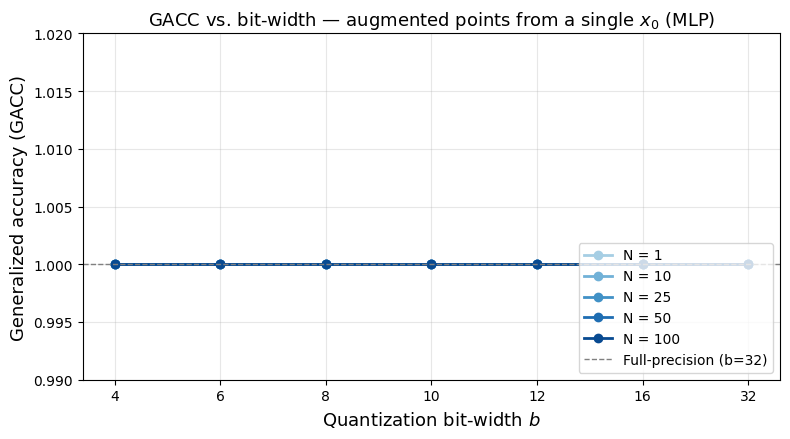

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/volumes_mlp_walk1point/gacc_vs_bits_1point.pdf


In [12]:
bits_arr = bits_grid + [32]
x_ticks  = list(range(len(bits_arr)))

# Colour map: lighter = fewer points, darker = more points
cmap   = plt.cm.Blues
colors = [cmap(0.35 + 0.55 * i / (len(SUBSET_SIZES) - 1))
          for i in range(len(SUBSET_SIZES))]

fig, ax = plt.subplots(figsize=(8, 4.5))

for color, n in zip(colors, SUBSET_SIZES):
    gacc_vals = [gacc_by_n[n][b] for b in bits_grid] + [1.0]   # append 32-bit reference
    ax.plot(x_ticks, gacc_vals,
            marker="o", linewidth=2, markersize=6,
            color=color, label=f"N = {n}")

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Full-precision (b=32)")

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Generalized accuracy (GACC)", fontsize=13)
ax.set_title(
    "GACC vs. bit-width — augmented points from a single $x_0$ (MLP)",
    fontsize=13,
)
ax.set_xticks(x_ticks)
ax.set_xticklabels(bits_arr)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.3)

# Leave y-axis autoscaled — GACC could be very close to 1 or noticeably below
ymin = min(gacc_by_n[n][b] for n in SUBSET_SIZES for b in bits_grid)
ax.set_ylim(max(0.0, ymin - 0.01), 1.02)

plt.tight_layout()
out_path = RESULTS_DIR / "gacc_vs_bits_1point.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved to", out_path)

## Summary table — GACC and error

Error = 1 − GACC.

In [13]:
print(f"{'N':>5}  {'bits':>5}  {'GACC':>10}  {'error (1-GACC)':>16}")
print("-" * 45)
for n in SUBSET_SIZES:
    for b in bits_grid:
        g = gacc_by_n[n][b]
        print(f"{n:>5}  {b:>5}  {g:>10.6f}  {1-g:>16.6f}")
    print()

    N   bits        GACC    error (1-GACC)
---------------------------------------------
    1      4    1.000000         -0.000000
    1      6    1.000000          0.000000
    1      8    1.000000          0.000000
    1     10    1.000000          0.000000
    1     12    1.000000          0.000000
    1     16    1.000000          0.000000

   10      4    1.000000         -0.000000
   10      6    1.000000         -0.000000
   10      8    1.000000         -0.000000
   10     10    1.000000          0.000000
   10     12    1.000000          0.000000
   10     16    1.000000          0.000000

   25      4    1.000000         -0.000000
   25      6    1.000000         -0.000000
   25      8    1.000000         -0.000000
   25     10    1.000000          0.000000
   25     12    1.000000          0.000000
   25     16    1.000000          0.000000

   50      4    1.000000         -0.000000
   50      6    1.000000         -0.000000
   50      8    1.000000         -0.000000
   50

## Inspect individual widths for sample 0 (= first walk representative)

Quick sanity check: compare P1, P2, P3 mean widths for the first augmented point.

In [14]:
r0 = records[0]
print(f"sample_idx = {r0['sample_idx']}")
print(f"  width_base   (P1) = {r0['width_base']:.4f}")
print()
print(f"  {'bits':>5}  {'W_correct (P2)':>16}  {'W_both (P3)':>13}  {'P3/P2':>8}  {'P2/P1':>8}")
print("  " + "-" * 60)
for b in bits_grid:
    wc = safe(r0["widths_correct"][str(b)])
    wb = safe(r0["widths_both"][str(b)])
    ratio_32 = wb / wc if wc > 0 else float("nan")
    ratio_p1 = wc / r0["width_base"] if r0["width_base"] > 0 else float("nan")
    print(f"  {b:>5}  {wc:>16.4f}  {wb:>13.4f}  {ratio_32:>8.6f}  {ratio_p1:>8.6f}")

sample_idx = 0
  width_base   (P1) = 39.7636

   bits    W_correct (P2)    W_both (P3)     P3/P2     P2/P1
  ------------------------------------------------------------
      4           37.5746        37.5746  1.000000  0.944949
      6           39.3043        39.3043  1.000000  0.988449
      8           39.6608        39.6608  1.000000  0.997416
     10           39.7097        39.7097  1.000000  0.998645
     12           39.7577        39.7577  1.000000  0.999851
     16           39.7633        39.7633  1.000000  0.999992


---
## GACC: q-correct vs. q-incorrect augmented points

We compare the generalized accuracy computed on three groups of augmented points:
- **q-correct** (100 points): augmented from original samples correctly classified by the 4-bit q-model
- **q-incorrect** (100 points): augmented from original samples *mis*classified by the 4-bit q-model
- **combined** (200 points): both groups together

Two plots: one for the MLP (Net1) and one for the CNN (Net2).

In [13]:
%load_ext autoreload
%autoreload 2

import os
import json
import math
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


In [59]:
def load_records(d):
    recs = []
    for f in sorted(Path(d).glob("volumes_sample*.json"),
                    key=lambda p: int(p.stem.split("sample")[1])):
        with open(f) as fh:
            recs.append(json.load(fh))
    return recs

def gacc(recs, bits_grid):
    def s(v): return 0.0 if (v is None or math.isnan(v)) else float(v)
    sc  = {b: sum(s(r["widths_correct"][str(b)]) for r in recs) for b in bits_grid}
    sb  = {b: sum(s(r["widths_both"][str(b)])    for r in recs) for b in bits_grid}
    return {b: (sb[b] / sc[b]) for b in bits_grid}

RESULTS = ROOT / "results"

data = {}
for model in ["mlp", "cnn"]:
    recs_c  = load_records(RESULTS / f"volumes_aug_{model}_qcorrect")
    recs_ic = load_records(RESULTS / f"volumes_aug_{model}_qincorrect")
    bits_grid = sorted(int(b) for b in recs_c[0]["widths_both"].keys())
    data[model] = {
        "bits_grid": bits_grid,
        "gacc_correct":   gacc(recs_c,              bits_grid),
        "gacc_incorrect":  gacc(recs_ic,             bits_grid),
        "gacc_all":        gacc(recs_c + recs_ic,   bits_grid),
    }
    print(f"{model.upper()} — loaded {len(recs_c)} q-correct, {len(recs_ic)} q-incorrect samples")

MLP — loaded 100 q-correct, 100 q-incorrect samples
CNN — loaded 100 q-correct, 100 q-incorrect samples


In [61]:
for i in range(100):
    print(i, "\t", recs_ic[i]["width_base"], recs_ic[i]["widths_correct"]["4"], recs_ic[i]["widths_both"]["4"])

0 	 1.8064712023318719 1.0469646416399991 1.042062078283625
1 	 1.7867634193688653 1.0423562048316553 1.0373169765923071
2 	 1.8010120010754234 1.0520534290844898 1.0464050254788964
3 	 1.8102287366464926 1.0493846423682343 1.0435978417916711
4 	 1.8090536328183162 1.0571063350352374 1.0517212659711694
5 	 1.8004401635095104 1.0505889369446222 1.0441849745722762
6 	 1.7893536594351749 1.0491783177772536 1.043241537923593
7 	 1.7896827423370056 1.036674948164186 1.031869641924321
8 	 1.7994455049607836 1.0469761693442323 1.0419419515951904
9 	 1.7895112154628992 1.04141118482282 1.036083601373295
10 	 1.188050819155677 0.6059933439009317 0.5921184336744809
11 	 1.2084881306241144 0.600777410019807 0.5852392854891143
12 	 1.1621049237791055 0.5837520508962087 0.5679450328480101
13 	 1.193533164922677 0.561502575013091 0.5420608141559615
14 	 1.1858745728134745 0.5677544859043787 0.5483584687749647
15 	 1.1955572172727222 0.566006068285919 0.5479046024233568
16 	 1.2046197962224772 0.6047

In [15]:
for model in ["mlp", "cnn"]:
    d = data[model]
    bits_grid = d["bits_grid"]
    print(f"\n=== {model.upper()} ===")
    print(f"  {'bits':>5}  {'GACC_correct':>14}  {'GACC_incorrect':>16}  {'GACC_all':>10}")
    print("  " + "-" * 55)
    for b in bits_grid:
        print(f"  {b:>5}  {d['gacc_correct'][b]:>14.6f}"
              f"  {d['gacc_incorrect'][b]:>16.6f}"
              f"  {d['gacc_all'][b]:>10.6f}")


=== MLP ===
   bits    GACC_correct    GACC_incorrect    GACC_all
  -------------------------------------------------------
      4        1.000000          0.966407    0.984734
      6        1.000000          1.000000    1.000000
      8        1.000000          0.999998    0.999999
     10        1.000000          0.999965    0.999983
     12        1.000000          1.000000    1.000000
     16        1.000000          1.000000    1.000000

=== CNN ===
   bits    GACC_correct    GACC_incorrect    GACC_all
  -------------------------------------------------------
      4        0.999987          0.941071    0.970467
      6        1.000000          1.000000    1.000000
      8        1.000000          0.999992    0.999996
     10        1.000000          0.999991    0.999996
     12        1.000000          1.000000    1.000000
     16        1.000000          1.000000    1.000000


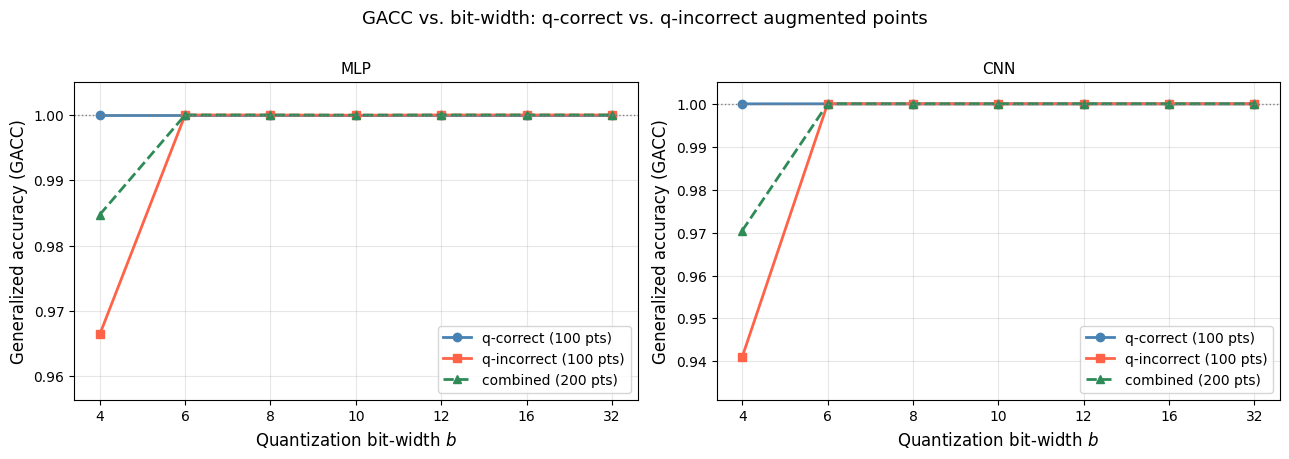

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/gacc_qcorrect_vs_qincorrect.pdf


In [16]:
MODEL_LABELS = {"mlp": "MLP",
                "cnn": "CNN"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, model in zip(axes, ["mlp", "cnn"]):
    d = data[model]
    bits_grid = d["bits_grid"]
    bits_arr  = bits_grid + [32]
    x_ticks   = list(range(len(bits_arr)))

    def vals(key):
        return [d[key][b] for b in bits_grid] + [1.0]

    ax.plot(x_ticks, vals("gacc_correct"),
            marker="o", linewidth=2, markersize=6,
            color="steelblue", label="q-correct (100 pts)")
    ax.plot(x_ticks, vals("gacc_incorrect"),
            marker="s", linewidth=2, markersize=6,
            color="tomato", label="q-incorrect (100 pts)")
    ax.plot(x_ticks, vals("gacc_all"),
            marker="^", linewidth=2, markersize=6,
            color="seagreen", linestyle="--", label="combined (200 pts)")

    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)

    ax.set_xlabel("Quantization bit-width $b$", fontsize=12)
    ax.set_ylabel("Generalized accuracy (GACC)", fontsize=12)
    ax.set_title(MODEL_LABELS[model], fontsize=11)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(bits_arr)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(True, alpha=0.3)

    all_vals = vals("gacc_correct") + vals("gacc_incorrect") + vals("gacc_all")
    ymin = min(v for v in all_vals if not math.isnan(v))
    ax.set_ylim(max(0.0, ymin - 0.01), 1.005)

fig.suptitle("GACC vs. bit-width: q-correct vs. q-incorrect augmented points",
             fontsize=13, y=1.01)
plt.tight_layout()

out_path = RESULTS / "figures" / "gacc_qcorrect_vs_qincorrect.pdf"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved to", out_path)

---
## Classical accuracy on augmented points

For each augmented point `x'` (indexed by `sample_idx` into the local `.pt` file),
we run the full-precision model and the q-models at each bit width and check whether
the predicted class matches the true label `c`.

- **fp model**: always predicts `c` correctly by construction (augmented points live inside
  $\\bar\\Xi_x$ where the fp model classifies correctly) → accuracy = 1.0 for all groups.
- **q-model at bit width $b$**: accuracy can be < 1, especially at low $b$ and for q-incorrect groups.

These accuracy curves are overlaid on the GACC plot (dashed lines, same colours).

In [17]:
import torch
import sys
sys.path.insert(0, str(ROOT))
from src.models.networks import FashionMLP_Large, FashionCNN_Small
from src.quantization.quantize import quantize_model

device = torch.device("cpu")

# ---- helper: run model on a single sample, return predicted class ----
@torch.no_grad()
def predict(model, x, model_type):
    """x: raw tensor from dataset (784,) for mlp or (1,28,28) for cnn."""
    inp = x.unsqueeze(0).to(device)   # add batch dim
    return int(model(inp).argmax(dim=1).item())

# ---- helper: compute accuracy dict {bits: acc} for a list of records ----
def compute_accuracy(recs, dataset, fp_model, qmodels, bits_grid, model_type):
    fp_model.eval()
    for qm in qmodels.values():
        qm.eval()
    n = len(recs)
    correct_fp = 0
    correct_q  = {b: 0 for b in bits_grid}
    for r in recs:
        x, c = dataset[r["sample_idx"]]
        c = int(c)
        if predict(fp_model, x, model_type) == c:
            correct_fp += 1
        for b in bits_grid:
            if predict(qmodels[b], x, model_type) == c:
                correct_q[b] += 1
    return {
        "fp": correct_fp / n,
        **{b: correct_q[b] / n for b in bits_grid},
    }

# ---- load results records (already done above in data{}) ----
# ---- load datasets, models, qmodels per model_type ----
ACC_DATA = {}
for model_type in ["mlp", "cnn"]:
    print(f"\n--- {model_type.upper()} ---")
    bits_grid = data[model_type]["bits_grid"]

    # Load fp model
    if model_type == "mlp":
        fp_model = FashionMLP_Large()
    else:
        fp_model = FashionCNN_Small()
    ckpt = ROOT / "checkpoints" / f"fashion_{model_type}_best.pth"
    fp_model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
    fp_model.eval()

    # Load q-models
    qmodels = {b: quantize_model(fp_model, bits=b).eval() for b in bits_grid}

    # Load augmented datasets
    ds_correct   = torch.load(ROOT / "data" / f"fashionMNIST_augmented_{model_type}_seed42_walk_qcorrect.pt",   weights_only=False)
    ds_incorrect = torch.load(ROOT / "data" / f"fashionMNIST_augmented_{model_type}_seed42_walk_qincorrect.pt", weights_only=False)

    # Load result records
    recs_c  = load_records(RESULTS / f"volumes_aug_{model_type}_qcorrect")
    recs_ic = load_records(RESULTS / f"volumes_aug_{model_type}_qincorrect")

    acc_c  = compute_accuracy(recs_c,  ds_correct,   fp_model, qmodels, bits_grid, model_type)
    acc_ic = compute_accuracy(recs_ic, ds_incorrect,  fp_model, qmodels, bits_grid, model_type)

    # Combined: recs from qcorrect use ds_correct, recs from qincorrect use ds_incorrect
    # Compute combined accuracy directly
    n_all = len(recs_c) + len(recs_ic)
    acc_all = {
        "fp": (acc_c["fp"] * len(recs_c) + acc_ic["fp"] * len(recs_ic)) / n_all,
        **{b: (acc_c[b] * len(recs_c) + acc_ic[b] * len(recs_ic)) / n_all
           for b in bits_grid},
    }

    ACC_DATA[model_type] = {
        "bits_grid": bits_grid,
        "acc_correct":   acc_c,
        "acc_incorrect": acc_ic,
        "acc_all":       acc_all,
    }

    print(f"  {'bits':>5}  {'acc_correct':>12}  {'acc_incorrect':>14}  {'acc_all':>9}")
    print("  " + "-" * 50)
    for b in bits_grid:
        print(f"  {b:>5}  {acc_c[b]:>12.4f}  {acc_ic[b]:>14.4f}  {acc_all[b]:>9.4f}")
    print(f"  {'fp':>5}  {acc_c['fp']:>12.4f}  {acc_ic['fp']:>14.4f}  {acc_all['fp']:>9.4f}")


--- MLP ---
   bits   acc_correct   acc_incorrect    acc_all
  --------------------------------------------------
      4        1.0000          0.1000     0.5500
      6        1.0000          1.0000     1.0000
      8        1.0000          1.0000     1.0000
     10        1.0000          1.0000     1.0000
     12        1.0000          1.0000     1.0000
     16        1.0000          1.0000     1.0000
     fp        1.0000          1.0000     1.0000

--- CNN ---
   bits   acc_correct   acc_incorrect    acc_all
  --------------------------------------------------
      4        1.0000          0.0000     0.5000
      6        1.0000          1.0000     1.0000
      8        1.0000          1.0000     1.0000
     10        1.0000          1.0000     1.0000
     12        1.0000          1.0000     1.0000
     16        1.0000          1.0000     1.0000
     fp        1.0000          1.0000     1.0000


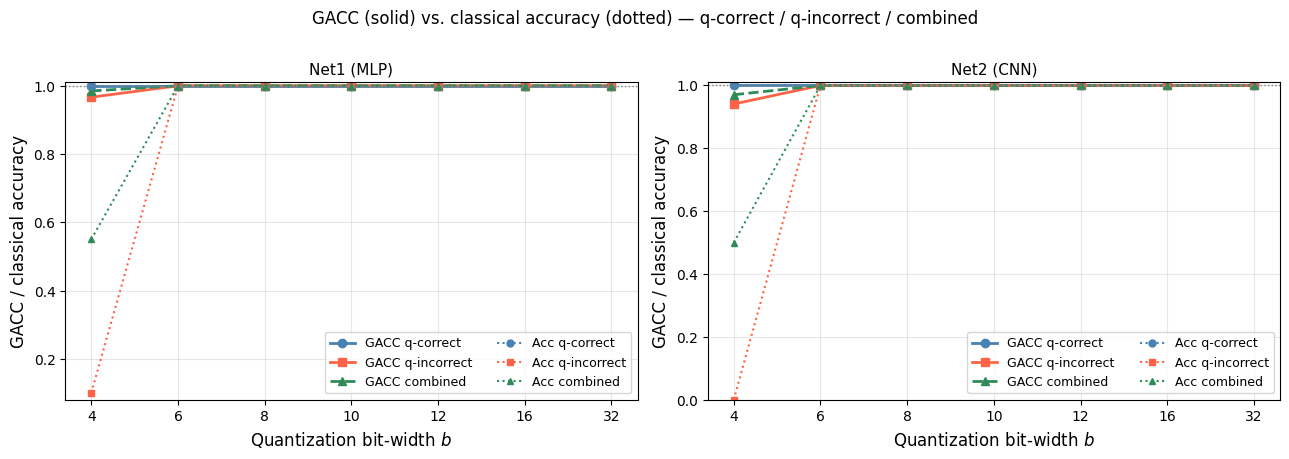

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/gacc_vs_acc_qcorrect_qincorrect.pdf


In [6]:
MODEL_LABELS = {"mlp": "Net1 (MLP)", "cnn": "Net2 (CNN)"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, model_type in zip(axes, ["mlp", "cnn"]):
    d   = data[model_type]
    acc = ACC_DATA[model_type]
    bits_grid = d["bits_grid"]
    bits_arr  = bits_grid + [32]
    x_ticks   = list(range(len(bits_arr)))

    def gacc_vals(key): return [d[key][b] for b in bits_grid] + [1.0]
    def acc_vals(key):  return [acc[key][b] for b in bits_grid] + [acc[key]["fp"]]

    ax.plot(x_ticks, gacc_vals("gacc_correct"),
            marker="o", linewidth=2, markersize=6, color="steelblue", label="GACC q-correct")
    ax.plot(x_ticks, gacc_vals("gacc_incorrect"),
            marker="s", linewidth=2, markersize=6, color="tomato",    label="GACC q-incorrect")
    ax.plot(x_ticks, gacc_vals("gacc_all"),
            marker="^", linewidth=2, markersize=6, color="seagreen",  linestyle="--", label="GACC combined")
    ax.plot(x_ticks, acc_vals("acc_correct"),
            marker="o", linewidth=1.5, markersize=5, linestyle=":", color="steelblue", label="Acc q-correct")
    ax.plot(x_ticks, acc_vals("acc_incorrect"),
            marker="s", linewidth=1.5, markersize=5, linestyle=":", color="tomato",    label="Acc q-incorrect")
    ax.plot(x_ticks, acc_vals("acc_all"),
            marker="^", linewidth=1.5, markersize=5, linestyle=":", color="seagreen",  label="Acc combined")

    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Quantization bit-width $b$", fontsize=12)
    ax.set_ylabel("GACC / classical accuracy", fontsize=12)
    ax.set_title(MODEL_LABELS[model_type], fontsize=11)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(bits_arr)
    ax.legend(fontsize=9, loc="lower right", ncol=2)
    ax.grid(True, alpha=0.3)

    all_v = (gacc_vals("gacc_correct") + gacc_vals("gacc_incorrect") + gacc_vals("gacc_all")
             + acc_vals("acc_correct") + acc_vals("acc_incorrect") + acc_vals("acc_all"))
    ymin = min(v for v in all_v if not math.isnan(v))
    ax.set_ylim(max(0.0, ymin - 0.02), 1.01)

fig.suptitle(
    "GACC (solid) vs. classical accuracy (dotted) — q-correct / q-incorrect / combined",
    fontsize=12, y=1.01
)
plt.tight_layout()
out_path = RESULTS / "figures" / "gacc_vs_acc_qcorrect_qincorrect.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved to", out_path)


### Alternative: 2-row layout

Separates GACC (top row, zoomed to [0.90, 1.0]) from classical accuracy (bottom row, full scale [0, 1]).
Same colours as above; GACC uses solid lines, accuracy uses the same solid style since the panels are now separate.

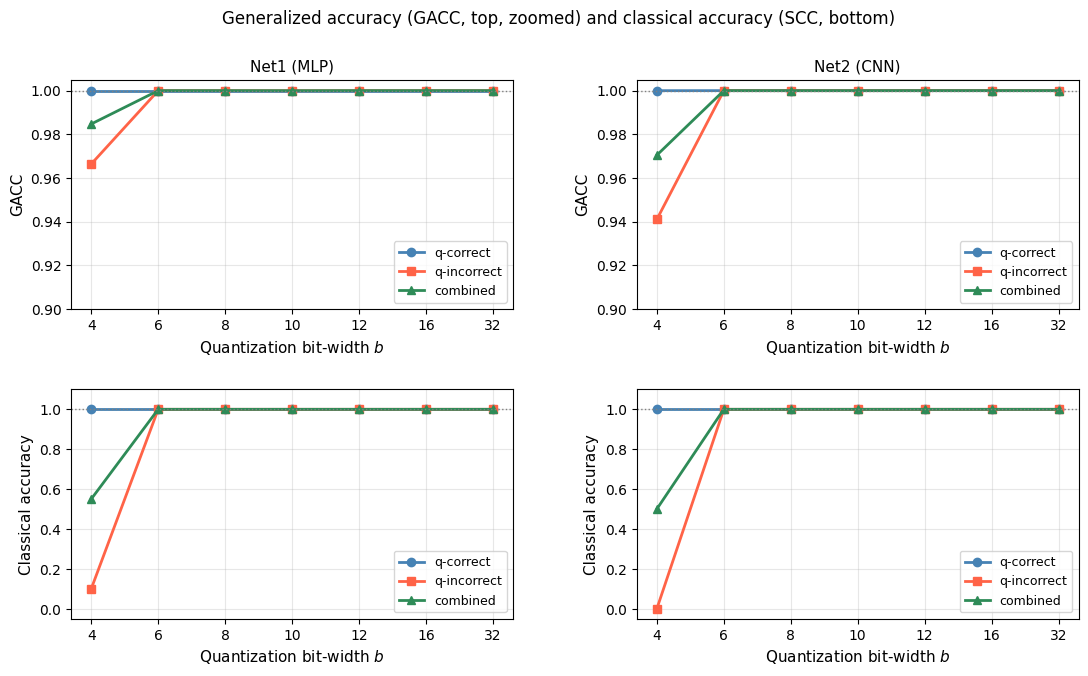

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/figures/gacc_vs_acc_2row.pdf


In [11]:
# Alternative: 2-row layout
# Row 0: GACC only, zoomed to [0.90, 1.005]  (MLP | CNN)
# Row 1: classical accuracy, full range [0, 1.05]  (MLP | CNN)

MODEL_LABELS = {"mlp": "Net1 (MLP)", "cnn": "Net2 (CNN)"}

fig, axes = plt.subplots(2, 2, figsize=(13, 7),
                          gridspec_kw={"hspace": 0.35, "wspace": 0.28})

for col, model_type in enumerate(["mlp", "cnn"]):
    ax_g = axes[0, col]   # GACC panel
    ax_a = axes[1, col]   # accuracy panel

    d   = data[model_type]
    acc = ACC_DATA[model_type]
    bits_grid = d["bits_grid"]
    bits_arr  = bits_grid + [32]
    x_ticks   = list(range(len(bits_arr)))

    def gv(key): return [d[key][b] for b in bits_grid] + [1.0]
    def av(key): return [acc[key][b] for b in bits_grid] + [acc[key]["fp"]]

    # --- top panel: GACC only (zoomed) ---
    ax_g.plot(x_ticks, gv("gacc_correct"),
              marker="o", lw=2, ms=6, color="steelblue", label="q-correct")
    ax_g.plot(x_ticks, gv("gacc_incorrect"),
              marker="s", lw=2, ms=6, color="tomato",    label="q-incorrect")
    ax_g.plot(x_ticks, gv("gacc_all"),
              marker="^", lw=2, ms=6, color="seagreen",  label="combined")
    ax_g.axhline(1.0, color="gray", ls=":", lw=1)
    ax_g.set_ylim(0.90, 1.005)
    ax_g.set_ylabel("GACC", fontsize=11)
    ax_g.set_title(MODEL_LABELS[model_type], fontsize=11)
    ax_g.set_xticks(x_ticks)
    ax_g.set_xticklabels(bits_arr)
    ax_g.set_xlabel("Quantization bit-width $b$", fontsize=11)
    ax_g.legend(fontsize=9, loc="lower right")
    ax_g.grid(True, alpha=0.3)

    # --- bottom panel: accuracy only (full scale) ---
    ax_a.plot(x_ticks, av("acc_correct"),
              marker="o", lw=2, ms=6, color="steelblue", label="q-correct")
    ax_a.plot(x_ticks, av("acc_incorrect"),
              marker="s", lw=2, ms=6, color="tomato",    label="q-incorrect")
    ax_a.plot(x_ticks, av("acc_all"),
              marker="^", lw=2, ms=6, color="seagreen",  label="combined")
    ax_a.axhline(1.0, color="gray", ls=":", lw=1)
    ax_a.set_ylim(-0.05, 1.10)
    ax_a.set_ylabel("Classical accuracy", fontsize=11)
    ax_a.set_xticks(x_ticks)
    ax_a.set_xticklabels(bits_arr)
    ax_a.set_xlabel("Quantization bit-width $b$", fontsize=11)
    ax_a.legend(fontsize=9, loc="lower right")
    ax_a.grid(True, alpha=0.3)

fig.suptitle(
    "Generalized accuracy (GACC, top, zoomed) and classical accuracy (SCC, bottom)",
    fontsize=12
)
out_path = RESULTS / "figures" / "gacc_vs_acc_2row.pdf"
plt.savefig(out_path, bbox_inches="tight")
plt.show()
print("Saved to", out_path)
